In [1]:
import requests
import pandas as pd
from io import StringIO

import matplotlib.pyplot as plt

plt.style.use("default")
%config InlineBackend.figure_format = "retina"

In [2]:
posts = requests.get("https://ix.cnn.io/data/truth-social/truth_archive.csv")

In [3]:
posts_df = pd.read_csv(
    StringIO(posts.content.decode("utf-8"))
)

In [4]:
posts_df["created_at"] = (
    pd.to_datetime(posts_df["created_at"], utc=True)
    .dt.tz_convert("America/New_York")
)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def datetime_to_hours(datetimes):
    """Convert pandas datetimes to decimal hours."""
    return (
        datetimes.dt.hour
        + datetimes.dt.minute / 60
        + datetimes.dt.second / 3600
        + datetimes.dt.microsecond / 3.6e9
    )


def circular_hist(
    hours,
    title="",
    center_text=None,
    bins=48,
    night=(18, 6),
    relative=True,
    donut=0.06,
    gap=0.92,
    n_rings=4,
    ring_label_hour=1.5,
    ring_label_fmt=None,
    ax=None,
):
    """
    Beautiful circular histogram of times of day.

    Parameters
    ----------
    hours : array-like
        Decimal hours in [0, 24).
    title : str
        Figure title.
    center_text : str, optional
        Text displayed in the donut hole.
    ring_label_hour : float, optional
        Clock hour (decimal, 0-24) at which to print the ring value labels.
        Defaults to 1.5 (1:30 AM), a spot usually low-activity/uncovered
        by bars. Set to None to disable ring labels entirely.
    ring_label_fmt : callable, optional
        Formats a ring value (float) into its label string. Defaults to
        "{:.0%}" when relative=True, otherwise "{:.0f}".
    """

    hours = np.asarray(hours) % 24
    theta = hours / 24 * 2 * np.pi

    counts, edges = np.histogram(
        theta,
        bins=bins,
        range=(0, 2 * np.pi),
    )

    if relative:
        counts = counts / counts.sum()

    centers = edges[:-1] + np.diff(edges) / 2
    widths = np.diff(edges) * gap

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(8, 8),
            subplot_kw={"projection": "polar"},
        )

    ax.set_title(title, fontsize=18, pad=25)

    # ----------------------------------------------------
    # Geometry
    # ----------------------------------------------------

    def hour_to_angle(hour):
        return hour / 24 * 2 * np.pi

    rmax = donut + counts.max() * 1.15

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_ylim(0, rmax)

    # ----------------------------------------------------
    # Night shading
    # ----------------------------------------------------

    start, end = night

    if start < end:
        spans = [(start, end)]
    else:
        spans = [(start, 24), (0, end)]

    for s, e in spans:
        ax.bar(
            hour_to_angle(s),
            rmax,
            width=hour_to_angle(e - s),
            bottom=0,
            align="edge",
            color="black",
            alpha=0.18,
            linewidth=0,
            zorder=0,
        )

    # ----------------------------------------------------
    # Colors
    # ----------------------------------------------------

    clock_cmap = LinearSegmentedColormap.from_list(
        "clock",
        [
            (0.00, "#23395B"),
            (0.18, "#355C7D"),
            (0.27, "#F8B500"),
            (0.50, "#FFD166"),
            (0.73, "#F08A5D"),
            (0.82, "#6C5B7B"),
            (1.00, "#23395B"),
        ],
    )

    colors = clock_cmap(centers / (2 * np.pi))

    # ----------------------------------------------------
    # Histogram
    # ----------------------------------------------------

    ax.bar(
        centers,
        counts,
        width=widths,
        bottom=donut,
        color=colors,
        edgecolor="white",
        linewidth=0.7,
        align="center",
        zorder=3,
    )

    # ----------------------------------------------------
    # Custom concentric circles
    # ----------------------------------------------------

    theta_dense = np.linspace(0, 2 * np.pi, 500)

    ring_radii = donut + np.linspace(
        counts.max() / n_rings,
        counts.max(),
        n_rings,
    )

    for r in ring_radii:
        ax.plot(
            theta_dense,
            np.full_like(theta_dense, r),
            color="gray",
            alpha=0.25,
            linewidth=0.8,
            zorder=1,
        )

    # ----------------------------------------------------
    # Ring value labels (placed at a fixed, low-activity clock
    # position so they land in open space rather than on top of bars)
    # ----------------------------------------------------

    if ring_label_hour is not None:
        if ring_label_fmt is None:
            ring_label_fmt = (lambda v: f"{v:.0%}") if relative else (lambda v: f"{v:.0f}")

        label_angle = hour_to_angle(ring_label_hour)
        ring_values = np.linspace(counts.max() / n_rings, counts.max(), n_rings)

        for r, val in zip(ring_radii, ring_values):
            ax.text(
                label_angle,
                r,
                ring_label_fmt(val),
                fontsize=8,
                color="gray",
                alpha=0.8,
                ha="center",
                va="center",
                zorder=2,
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.7,
                ),
            )

    # ----------------------------------------------------
    # Remove radial spokes inside donut
    # ----------------------------------------------------

    ax.xaxis.grid(False)
    ax.yaxis.grid(False)

    # Optional outer spokes only
    for angle in np.arange(0, 2 * np.pi, np.pi / 4):
        ax.plot(
            [angle, angle],
            [donut, rmax],
            color="gray",
            alpha=0.12,
            linewidth=0.8,
            zorder=1,
        )

    # ----------------------------------------------------
    # Labels
    # ----------------------------------------------------

    tick_hours = np.arange(0, 24, 3)

    ax.set_xticks(hour_to_angle(tick_hours))
    ax.set_xticklabels(
        [
            "Midnight",
            "3 AM",
            "6 AM",
            "9 AM",
            "Noon",
            "3 PM",
            "6 PM",
            "9 PM",
        ],
        fontsize=11,
    )

    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)

    # ----------------------------------------------------
    # Center text
    # ----------------------------------------------------

    if center_text is not None:
        ax.text(
            0.5,
            0.5,
            center_text,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            linespacing=1.3,
        )

    return ax

In [29]:
def analyze_daytime_posts(df, title="Trump Truth Social Post Frequency by Hour"):
    post_hours = datetime_to_hours(df["created_at"])

    # Compute post % between 9AM-Midnight
    in_time_range = (post_hours > 9) & (post_hours < 24)
    pct_in_time_range = np.sum(in_time_range) / len(in_time_range) * 100

    circular_hist(post_hours, title=title, center_text=f"{pct_in_time_range:.0f}% of Posts\n9 AM–Midnight", n_rings=6, donut=0.05)

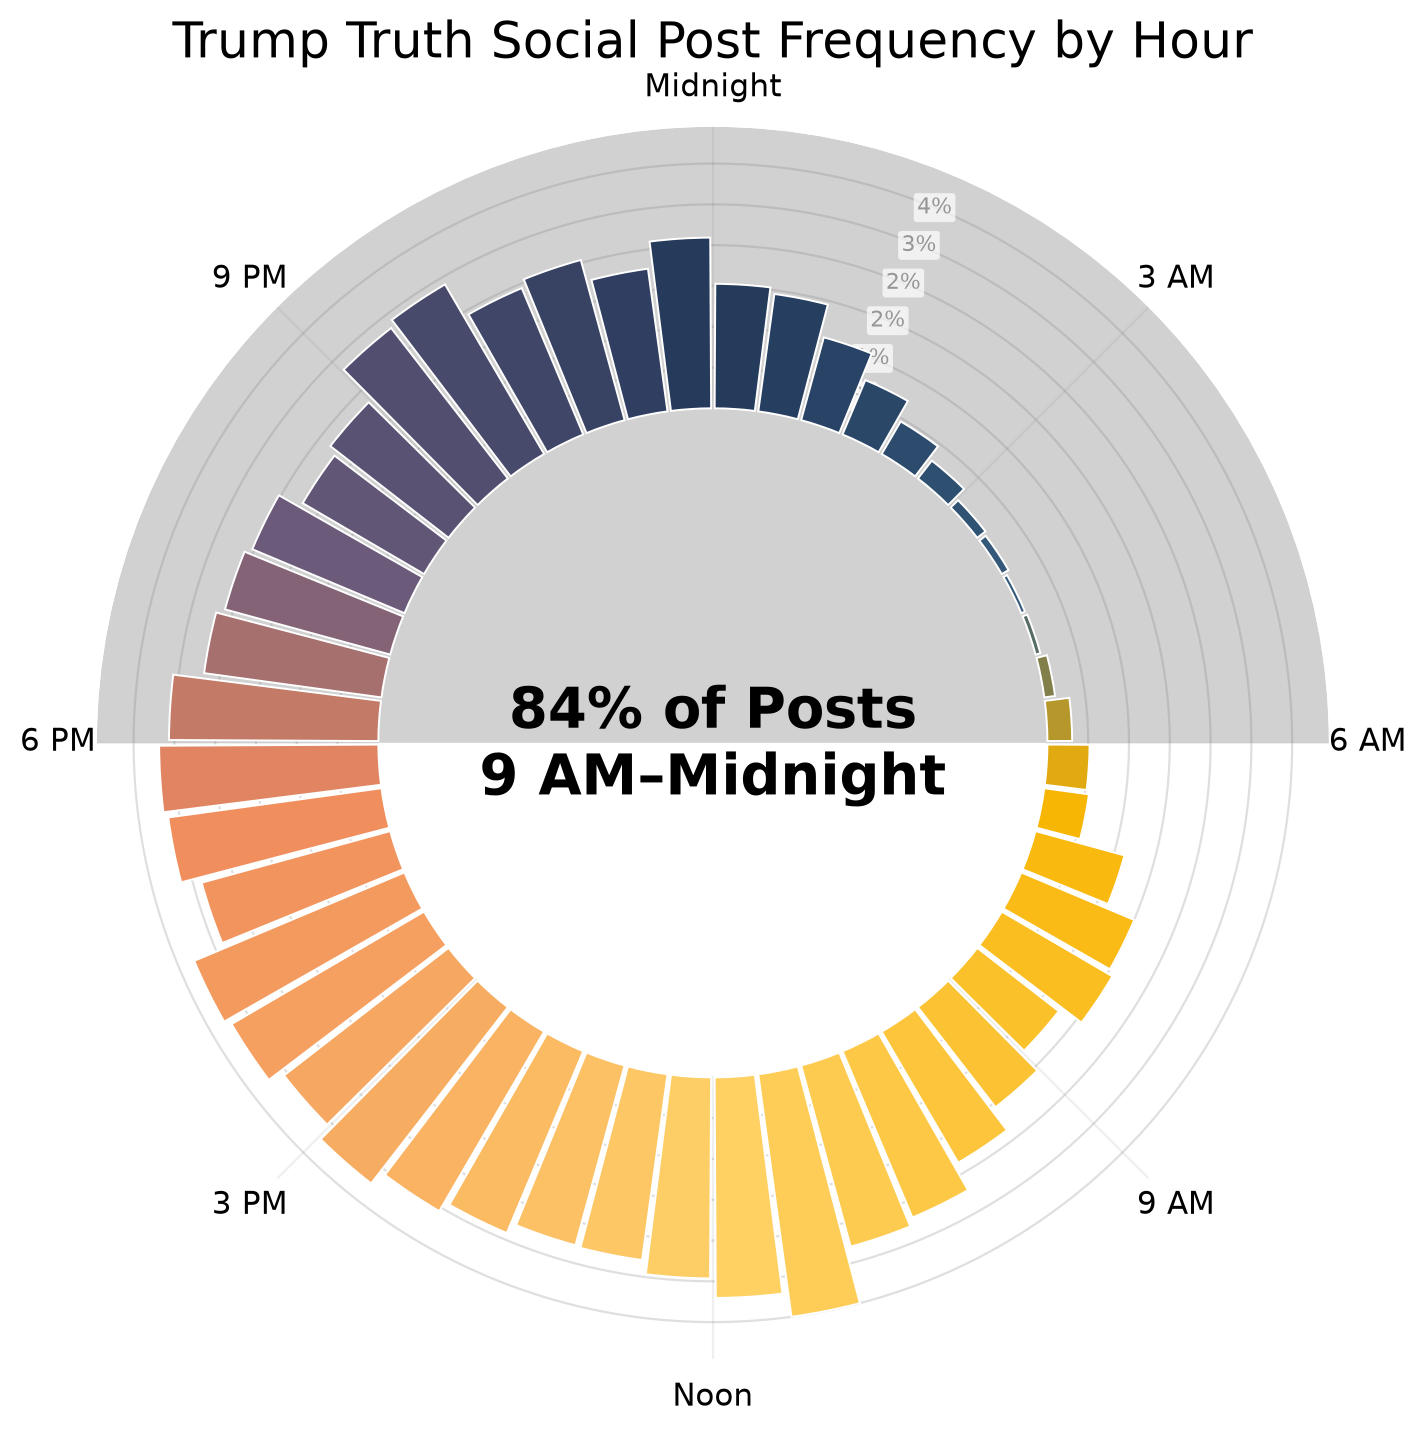

In [30]:
analyze_daytime_posts(posts_df)

In [23]:
during_second_term_df = posts_df[posts_df["created_at"] >= "2025-01-20"]
pre_second_term_df = posts_df[posts_df["created_at"] < "2025-01-20"]

In [24]:
during_second_term_df

,id,created_at,content,url,media,replies_count,reblogs_count,favourites_count
0,116910124906805108,2026-07-12 21:42:15.222000-04:00,RT: https://truthsocial.com/users/realDonaldTr...,https://truthsocial.com/@realDonaldTrump/11691...,https://static-assets-1.truthsocial.com/tmtg:p...,112,321,1200
1,116910001272572426,2026-07-12 21:10:48.712000-04:00,So sad!!! President DJT,https://truthsocial.com/@realDonaldTrump/11691...,https://static-assets-1.truthsocial.com/tmtg:p...,653,1134,4772
2,116909970912164568,2026-07-12 21:03:05.451000-04:00,59% Approval Rating. Prices coming down along ...,https://truthsocial.com/@realDonaldTrump/11690...,NaN,708,1141,5091
3,116909300964979990,2026-07-12 18:12:42.863000-04:00,https://www.youtube.com/watch?v=55mGpfhO-lg,https://truthsocial.com/@realDonaldTrump/11690...,NaN,1324,3547,11906
4,116908781848543413,2026-07-12 16:00:41.777000-04:00,"RT @realDonaldTrumpThank you to Ben Domenech, ...",https://truthsocial.com/@realDonaldTrump/11690...,NaN,0,0,1
...,...,...,...,...,...,...,...,...
9938,113865263826581861,2025-01-21 02:54:02.276000-05:00,RT @TeamTrump🚨 President Trump signs an order ...,https://truthsocial.com/@realDonaldTrump/11386...,NaN,0,0,0
9939,113865263505732740,2025-01-21 02:53:57.380000-05:00,RT @TeamTrump🚨 President Trump withdraws the U...,https://truthsocial.com/@realDonaldTrump/11386...,NaN,0,0,0
9940,113865263237260004,2025-01-21 02:53:53.284000-05:00,"RT @TeamTrumpThanks to President Trump, Americ...",https://truthsocial.com/@realDonaldTrump/11386...,NaN,0,0,0
9941,113864692804149616,2025-01-21 00:28:49.169000-05:00,Our first day in the White House is not over y...,https://truthsocial.com/@realDonaldTrump/11386...,NaN,6448,18133,87225


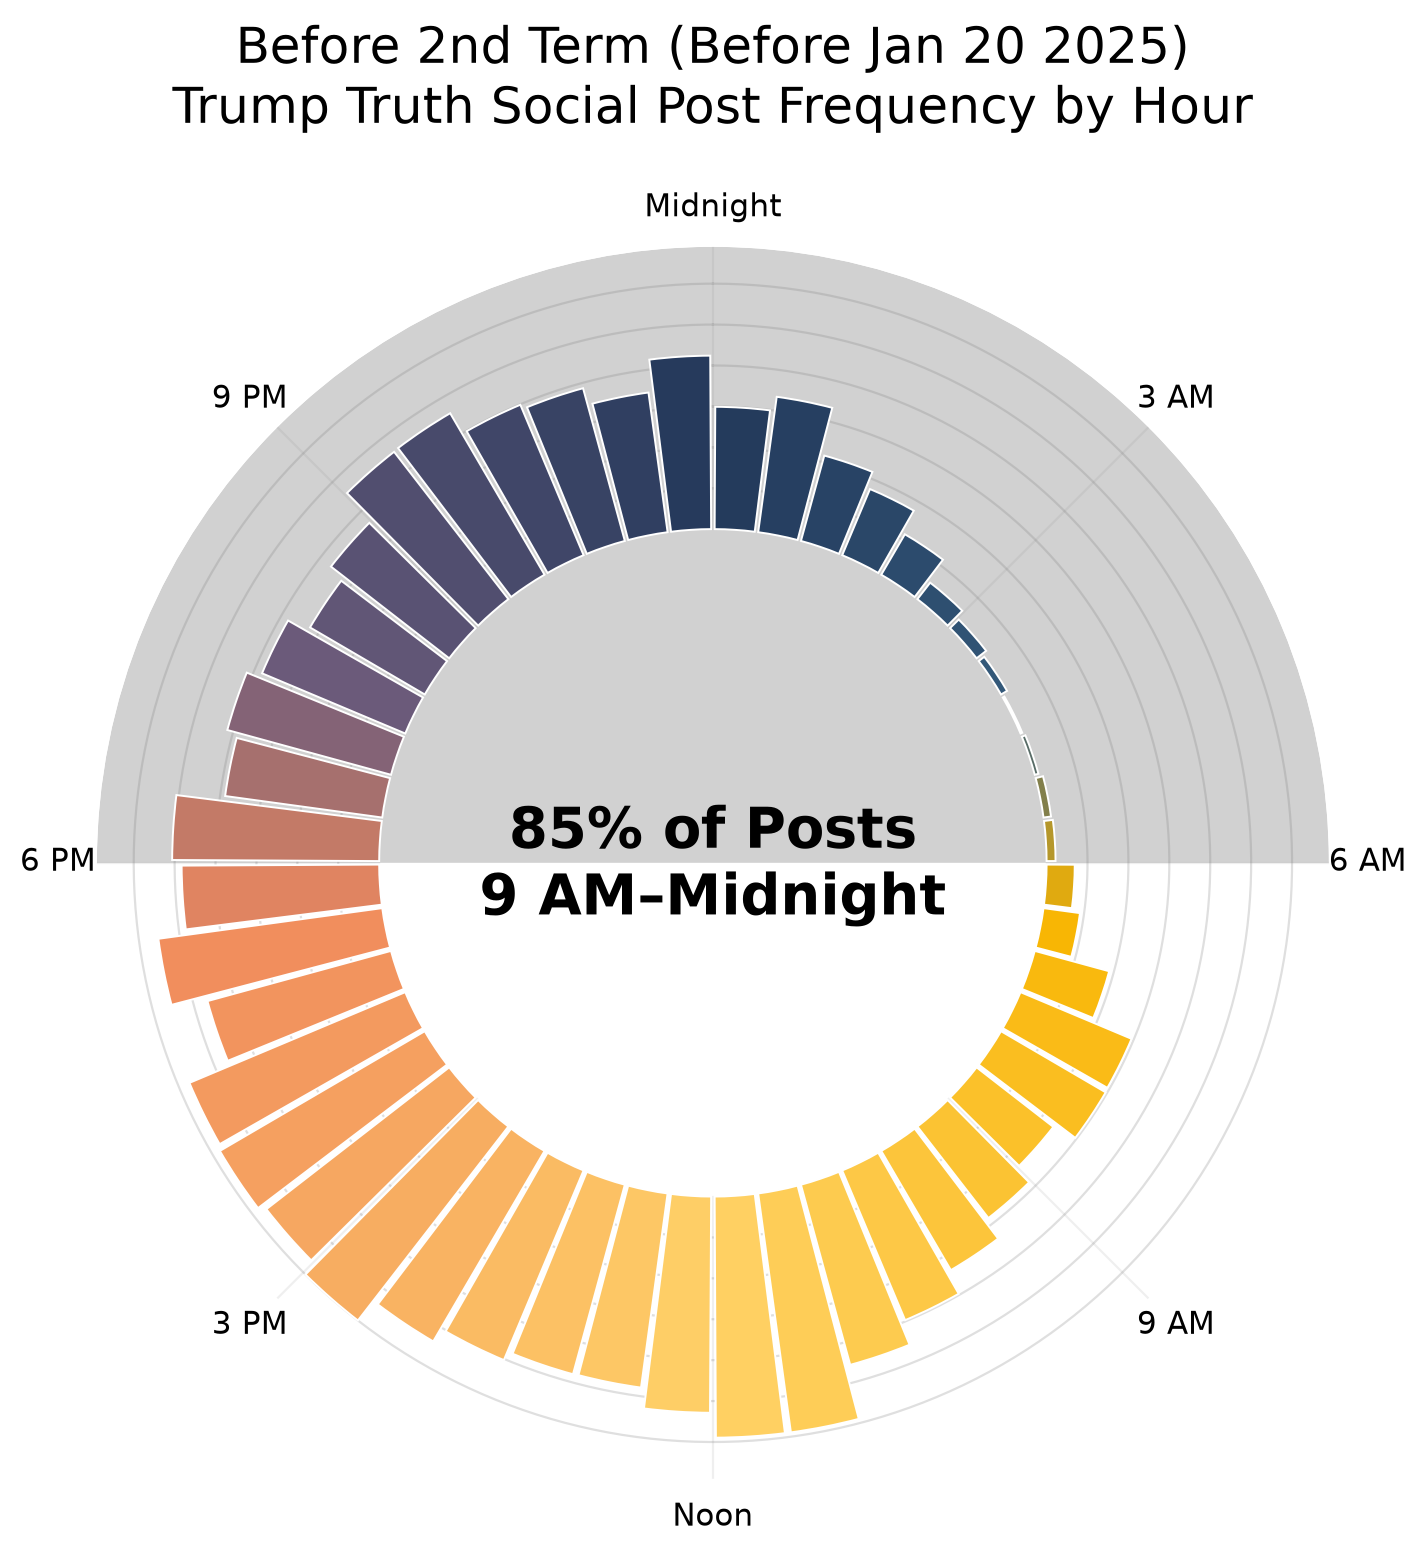

In [25]:
analyze_daytime_posts(pre_second_term_df, title="Before 2nd Term (Before Jan 20 2025)\nTrump Truth Social Post Frequency by Hour")

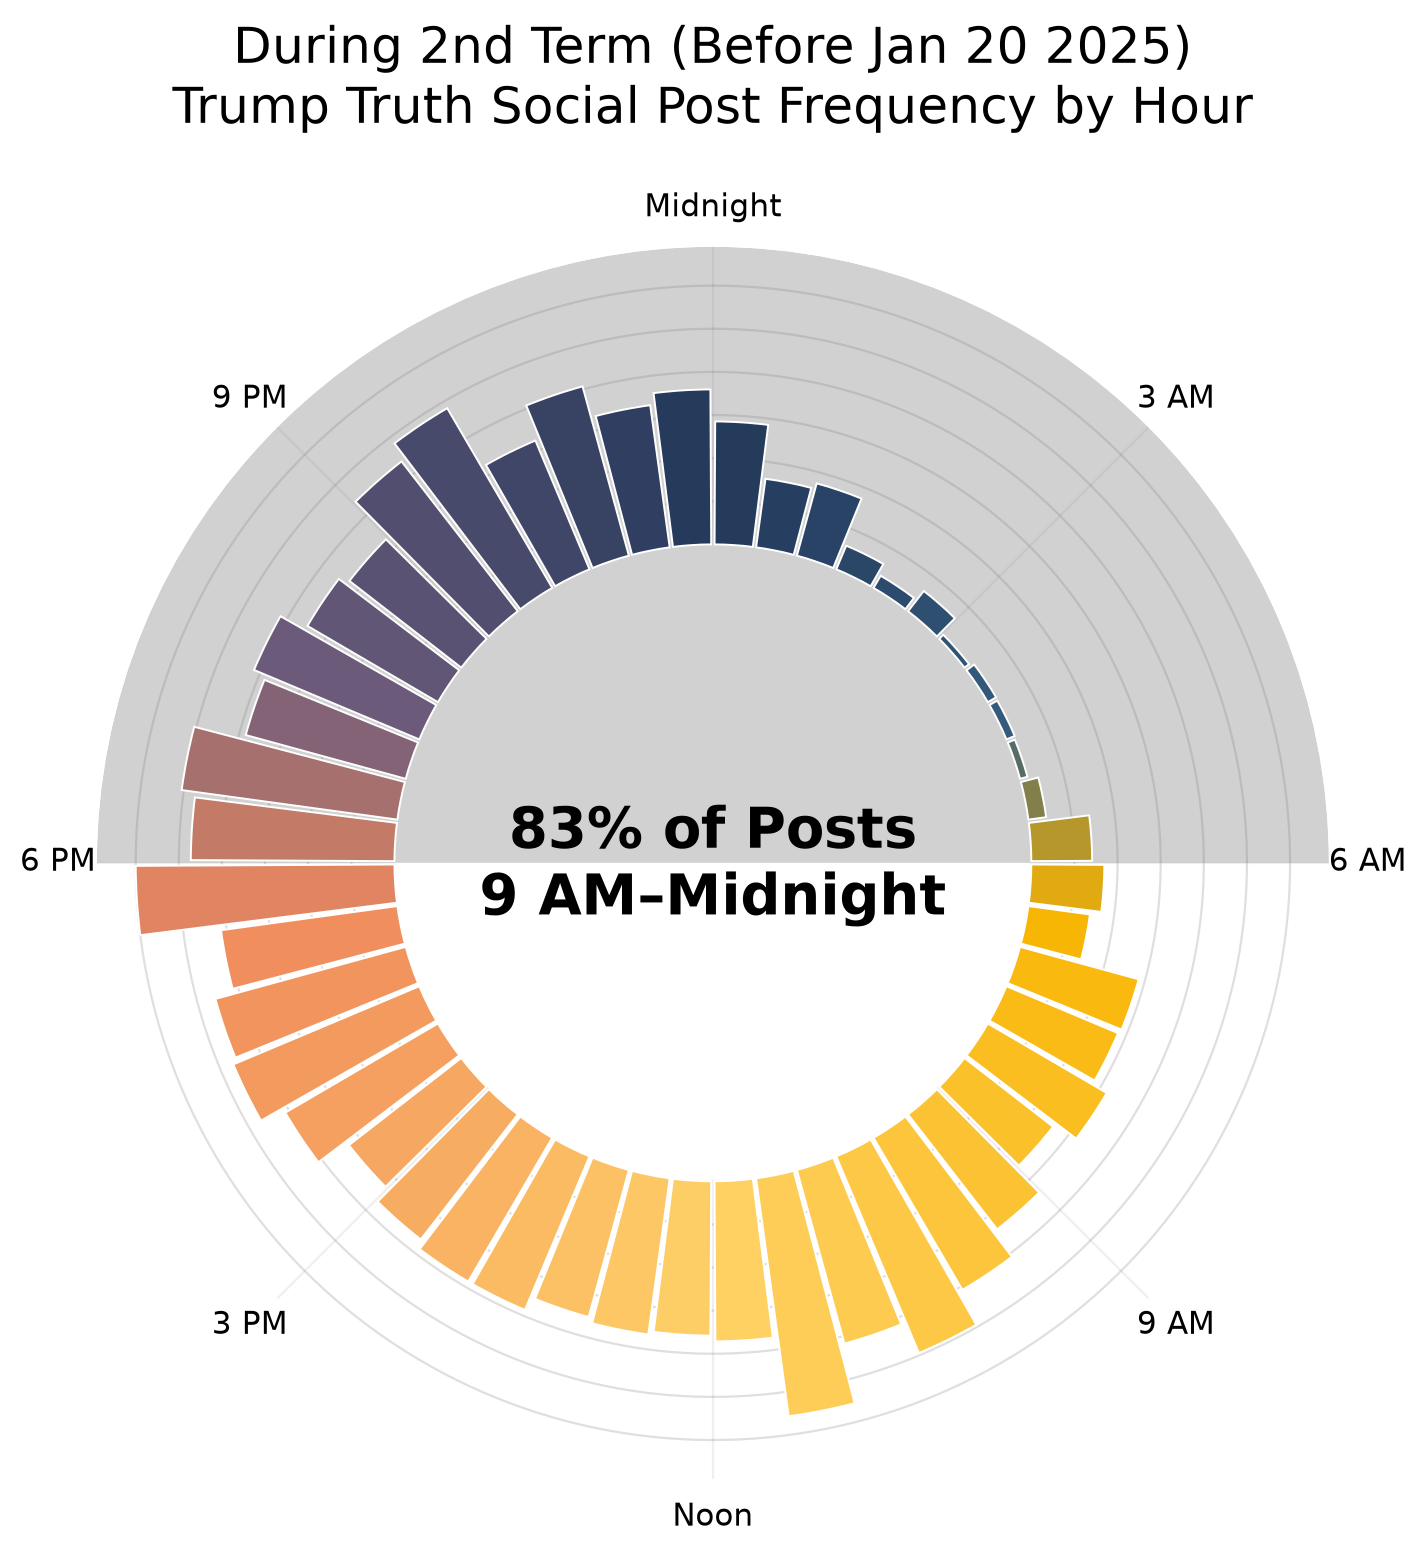

In [26]:
analyze_daytime_posts(during_second_term_df, title="During 2nd Term (Before Jan 20 2025)\nTrump Truth Social Post Frequency by Hour")

In [75]:
"""
Infer wake-up / fall-asleep times per month from post timestamps, by
aggregating each month's posts into a "typical day" activity profile
(a histogram over hour-of-day, circular) and finding the quietest
contiguous window on that circle.

This sidesteps the per-post noise problems of the earlier HMM approach:
by summing ~a month of days into ~96 bins (15-min resolution), a single
stray post can no longer flip a state; the signal is the shape of the
aggregate profile, not any individual bin.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# 1. Build one hour-of-day histogram per month
# ---------------------------------------------------------------------------

def monthly_hour_histograms(post_datetimes: pd.Series, freq_minutes=15, display_tz=None, n_months=1):
    """
    Returns a DataFrame: rows = period label, columns = bin index
    (0 .. n_bins-1, where bin i covers [i*freq_minutes, (i+1)*freq_minutes)
    minutes past local midnight), values = total post count in that bin,
    summed across every day in that period.

    n_months: width of each aggregation window, in months. 1 = calendar
        months (original behavior). Use e.g. 6 to pool 6 calendar months
        of data into each histogram when monthly data is too sparse/noisy.
        Windows are anchored to the FIRST post's month and are non-overlapping,
        e.g. n_months=6 on data starting 2022-03 gives windows
        2022-03..2022-08, 2022-09..2023-02, etc. The last window may be
        shorter than n_months if the data doesn't divide evenly -- check
        `n_posts` per row (added by infer_monthly_sleep_windows) since a
        short trailing window is effectively a low-sample-size period.
    """
    s = pd.to_datetime(post_datetimes)
    if s.dt.tz is None:
        s = s.dt.tz_localize("UTC")
    else:
        s = s.dt.tz_convert("UTC")
    if display_tz is not None:
        s = s.dt.tz_convert(display_tz)   # local time matters -- sleep is a local-clock phenomenon

    n_bins = int(24 * 60 / freq_minutes)
    bin_idx = ((s.dt.hour * 60 + s.dt.minute) // freq_minutes).astype(int)

    # year_month buckets don't need to carry tz info -- the tz already did
    # its job above when computing each post's LOCAL hour-of-day. Suppress
    # the expected "drops timezone information" warning explicitly rather
    # than letting it fire silently on every call.
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, message=".*drop timezone information.*")
        year_month = s.dt.to_period("M")

    if n_months == 1:
        period = year_month.astype(str)
    else:
        # bucket calendar months into non-overlapping n_months-wide windows,
        # anchored at the first month present in the data
        anchor = year_month.min()
        months_since_anchor = (year_month - anchor).map(lambda o: o.n if hasattr(o, "n") else int(o))
        window_idx = months_since_anchor // n_months
        # label each window by its first month, e.g. "2022-03" for a
        # window covering 2022-03 through 2022-08
        period = (anchor + window_idx * n_months).astype(str)

    df = pd.DataFrame({"period": period, "bin_idx": bin_idx})
    hist = df.groupby(["period", "bin_idx"]).size().unstack(fill_value=0)
    hist = hist.reindex(columns=range(n_bins), fill_value=0)
    hist.columns.name = "bin_idx"
    return hist


# ---------------------------------------------------------------------------
# 2. Find the quietest contiguous window on the 24h circle (per month)
# ---------------------------------------------------------------------------

def infer_sleep_window(bin_counts, freq_minutes=15, min_hours=3, max_hours=11):
    """
    bin_counts: 1D array, length n_bins, circular (bin_idx wraps midnight).
    Searches all (start, width) combos with width in [min_hours, max_hours]
    and picks the one maximizing contrast between the window's mean rate
    and the rest-of-day's mean rate. Handles windows that wrap past
    midnight natively (it's a circular search).

    Returns: (start_bin, end_bin, width_hours, contrast)
      start_bin = inferred fall-asleep bin, end_bin = inferred wake-up bin
      (end_bin is exclusive, i.e. the window is [start_bin, end_bin) mod n)
    """
    n = len(bin_counts)
    total = bin_counts.sum()
    min_w = max(1, int(round(min_hours * 60 / freq_minutes)))
    max_w = int(round(max_hours * 60 / freq_minutes))

    # cumulative sum trick for O(n) per width instead of O(n) per (start,width)
    doubled = np.concatenate([bin_counts, bin_counts])  # handle wraparound
    csum = np.concatenate([[0], np.cumsum(doubled)])

    best = None  # (contrast, start, width)
    for w in range(min_w, max_w + 1):
        window_sums = csum[w:w + n] - csum[0:n]  # window starting at each start in [0, n)
        window_rate = window_sums / w
        rest_sums = total - window_sums
        rest_rate = rest_sums / (n - w)
        contrast = rest_rate - window_rate
        start = int(np.argmax(contrast))
        c = contrast[start]
        if best is None or c > best[0]:
            best = (c, start, w)

    contrast, start, w = best
    end = (start + w) % n
    width_hours = w * freq_minutes / 60
    return start, end, width_hours, contrast


def infer_monthly_sleep_windows(hist, freq_minutes=15, min_hours=3, max_hours=11, min_posts=50):
    """
    Applies infer_sleep_window to every month in `hist`.
    min_posts: months with fewer total posts than this are still computed
        but flagged (low_confidence=True) since the histogram is probably
        too sparse to trust -- filter these out of trend plots as needed.
    """
    records = []
    for ym, row in hist.iterrows():
        counts = row.to_numpy()
        start, end, width_hours, contrast = infer_sleep_window(
            counts, freq_minutes, min_hours, max_hours
        )
        fall_asleep_hour = start * freq_minutes / 60
        wake_up_hour = end * freq_minutes / 60
        records.append({
            "year_month": ym,
            "fall_asleep_hour": fall_asleep_hour,
            "wake_up_hour": wake_up_hour,
            "sleep_duration_hours": width_hours,
            "contrast": contrast,
            "n_posts": int(counts.sum()),
            "low_confidence": int(counts.sum()) < min_posts,
        })
    out = pd.DataFrame(records).set_index("year_month").sort_index()
    return out


# ---------------------------------------------------------------------------
# 3. Debug plot: one month's histogram + inferred window
# ---------------------------------------------------------------------------

def plot_month_debug(hist, monthly_windows, period, freq_minutes=15):
    """
    period: the period label as it appears in hist.index, e.g. "2024-03"
        (n_months=1) or the window-start label produced when n_months>1
        (e.g. "2022-03" for a 6-month window covering 2022-03..2022-08).
        Run `hist.index.tolist()` if you're not sure of the exact label.
    """
    p = str(period)
    counts = hist.loc[p].to_numpy()
    n_bins = len(counts)
    hours = np.arange(n_bins) * freq_minutes / 60

    row = monthly_windows.loc[p]
    start_h, end_h = row["fall_asleep_hour"], row["wake_up_hour"]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(hours, counts, width=freq_minutes / 60 * 0.9, color="black", alpha=0.7)

    # shade inferred sleep window; handle wraparound past midnight
    if start_h < end_h:
        ax.axvspan(start_h, end_h, color="steelblue", alpha=0.25)
    else:
        ax.axvspan(start_h, 24, color="steelblue", alpha=0.25)
        ax.axvspan(0, end_h, color="steelblue", alpha=0.25)

    ax.axvline(start_h, color="crimson", ls="--", lw=1.5, label=f"fall asleep ~{start_h:.2f}h")
    ax.axvline(end_h, color="seagreen", ls="--", lw=1.5, label=f"wake up ~{end_h:.2f}h")

    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlabel("hour of day (local)")
    ax.set_ylabel(f"total posts in this {freq_minutes}-min bin, across the period")
    ax.set_title(
        f"{p}  |  n_posts={int(row['n_posts'])}  |  "
        f"inferred sleep duration={row['sleep_duration_hours']:.1f}h"
        + ("  [LOW CONFIDENCE: sparse period]" if row["low_confidence"] else "")
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 4. Trend plot: wake/sleep times over months/years
# ---------------------------------------------------------------------------

def plot_sleep_trend(monthly_windows, drop_low_confidence=True):
    """
    Plot inferred sleep intervals.

    Left panel:
        • left dot  = fall asleep
        • right dot = wake up
        • connecting line = inferred sleep interval
        • numeric sleep duration beside each interval

    Right panel:
        Horizontal bar chart of inferred sleep duration.
    """

    df = monthly_windows.copy()

    if drop_low_confidence:
        df = df[~df["low_confidence"]]

    if len(df) == 0:
        print("No periods to plot.")
        return df

    df = df.sort_index()

    # ------------------------------------------------------------------
    # Display bedtimes continuously:
    # 22:00 -> 22
    # 23:30 -> 23.5
    # 00:30 -> 24.5
    # 02:00 -> 26
    # ------------------------------------------------------------------

    bedtime = df["fall_asleep_hour"].where(
        df["fall_asleep_hour"] >= 12,
        df["fall_asleep_hour"] + 24,
    )

    wake = df["wake_up_hour"].copy()

    wake_display = wake.copy()
    wake_display[wake_display < bedtime] += 24

    y = np.arange(len(df))

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------

    fig, (ax_time, ax_dur) = plt.subplots(
        1,
        2,
        figsize=(15, max(6, len(df) * 0.35)),
        sharey=True,
        gridspec_kw={"width_ratios": [4.5, 1.5]},
    )

    # ------------------------------------------------------------------
    # Left panel: sleep interval
    # ------------------------------------------------------------------

    for i in range(len(df)):
        ax_time.plot(
            [bedtime.iloc[i], wake_display.iloc[i]],
            [y[i], y[i]],
            color="steelblue",
            lw=2,
            zorder=1,
        )

    ax_time.scatter(
        bedtime,
        y,
        color="crimson",
        s=45,
        zorder=3,
        label="Fall asleep",
    )

    ax_time.scatter(
        wake_display,
        y,
        color="seagreen",
        s=45,
        zorder=3,
        label="Wake up",
    )

    # Duration labels beside wake-up dot
    for yi, wake_x, duration in zip(
        y,
        wake_display,
        df["sleep_duration_hours"],
    ):
        ax_time.text(
            wake_x + 0.18,
            yi,
            f"{duration:.1f} h",
            va="center",
            ha="left",
            fontsize=8,
            color="dimgray",
        )

    ticks = np.arange(20, 37, 2)

    ax_time.set_xticks(ticks)
    ax_time.set_xticklabels(
        [f"{int(t % 24):02d}:00" for t in ticks]
    )

    ax_time.set_xlim(20, 36)

    ax_time.set_yticks(y)
    ax_time.set_yticklabels(df.index)

    ax_time.invert_yaxis()

    ax_time.grid(axis="x", alpha=0.3)

    ax_time.set_xlabel("Local clock time")
    ax_time.set_ylabel("Period")
    ax_time.set_title("Inferred sleep interval")

    ax_time.legend(loc="upper left")

    # ------------------------------------------------------------------
    # Right panel: duration histogram/bar chart
    # ------------------------------------------------------------------

    bars = ax_dur.barh(
        y,
        df["sleep_duration_hours"],
        color="steelblue",
        height=0.6,
    )

    xmax = max(10, np.ceil(df["sleep_duration_hours"].max()) + 0.5)
    ax_dur.set_xlim(0, xmax)

    ax_dur.set_xlabel("Hours")
    ax_dur.set_title("Sleep duration")

    ax_dur.grid(axis="x", alpha=0.3)

    # Numeric labels
    for bar, duration in zip(bars, df["sleep_duration_hours"]):
        ax_dur.text(
            duration + 0.08,
            bar.get_y() + bar.get_height() / 2,
            f"{duration:.1f}",
            va="center",
            fontsize=8,
        )

    # Hide duplicate y-axis labels
    ax_dur.tick_params(axis="y", left=False, labelleft=False)

    plt.tight_layout()
    plt.show()

    return df

In [76]:
hist = monthly_hour_histograms(posts_df["created_at"], display_tz="America/New_York", n_months=6)
print(hist.index.tolist())

['2022-02', '2022-08', '2023-02', '2023-08', '2024-02', '2024-08', '2025-02', '2025-08', '2026-02']


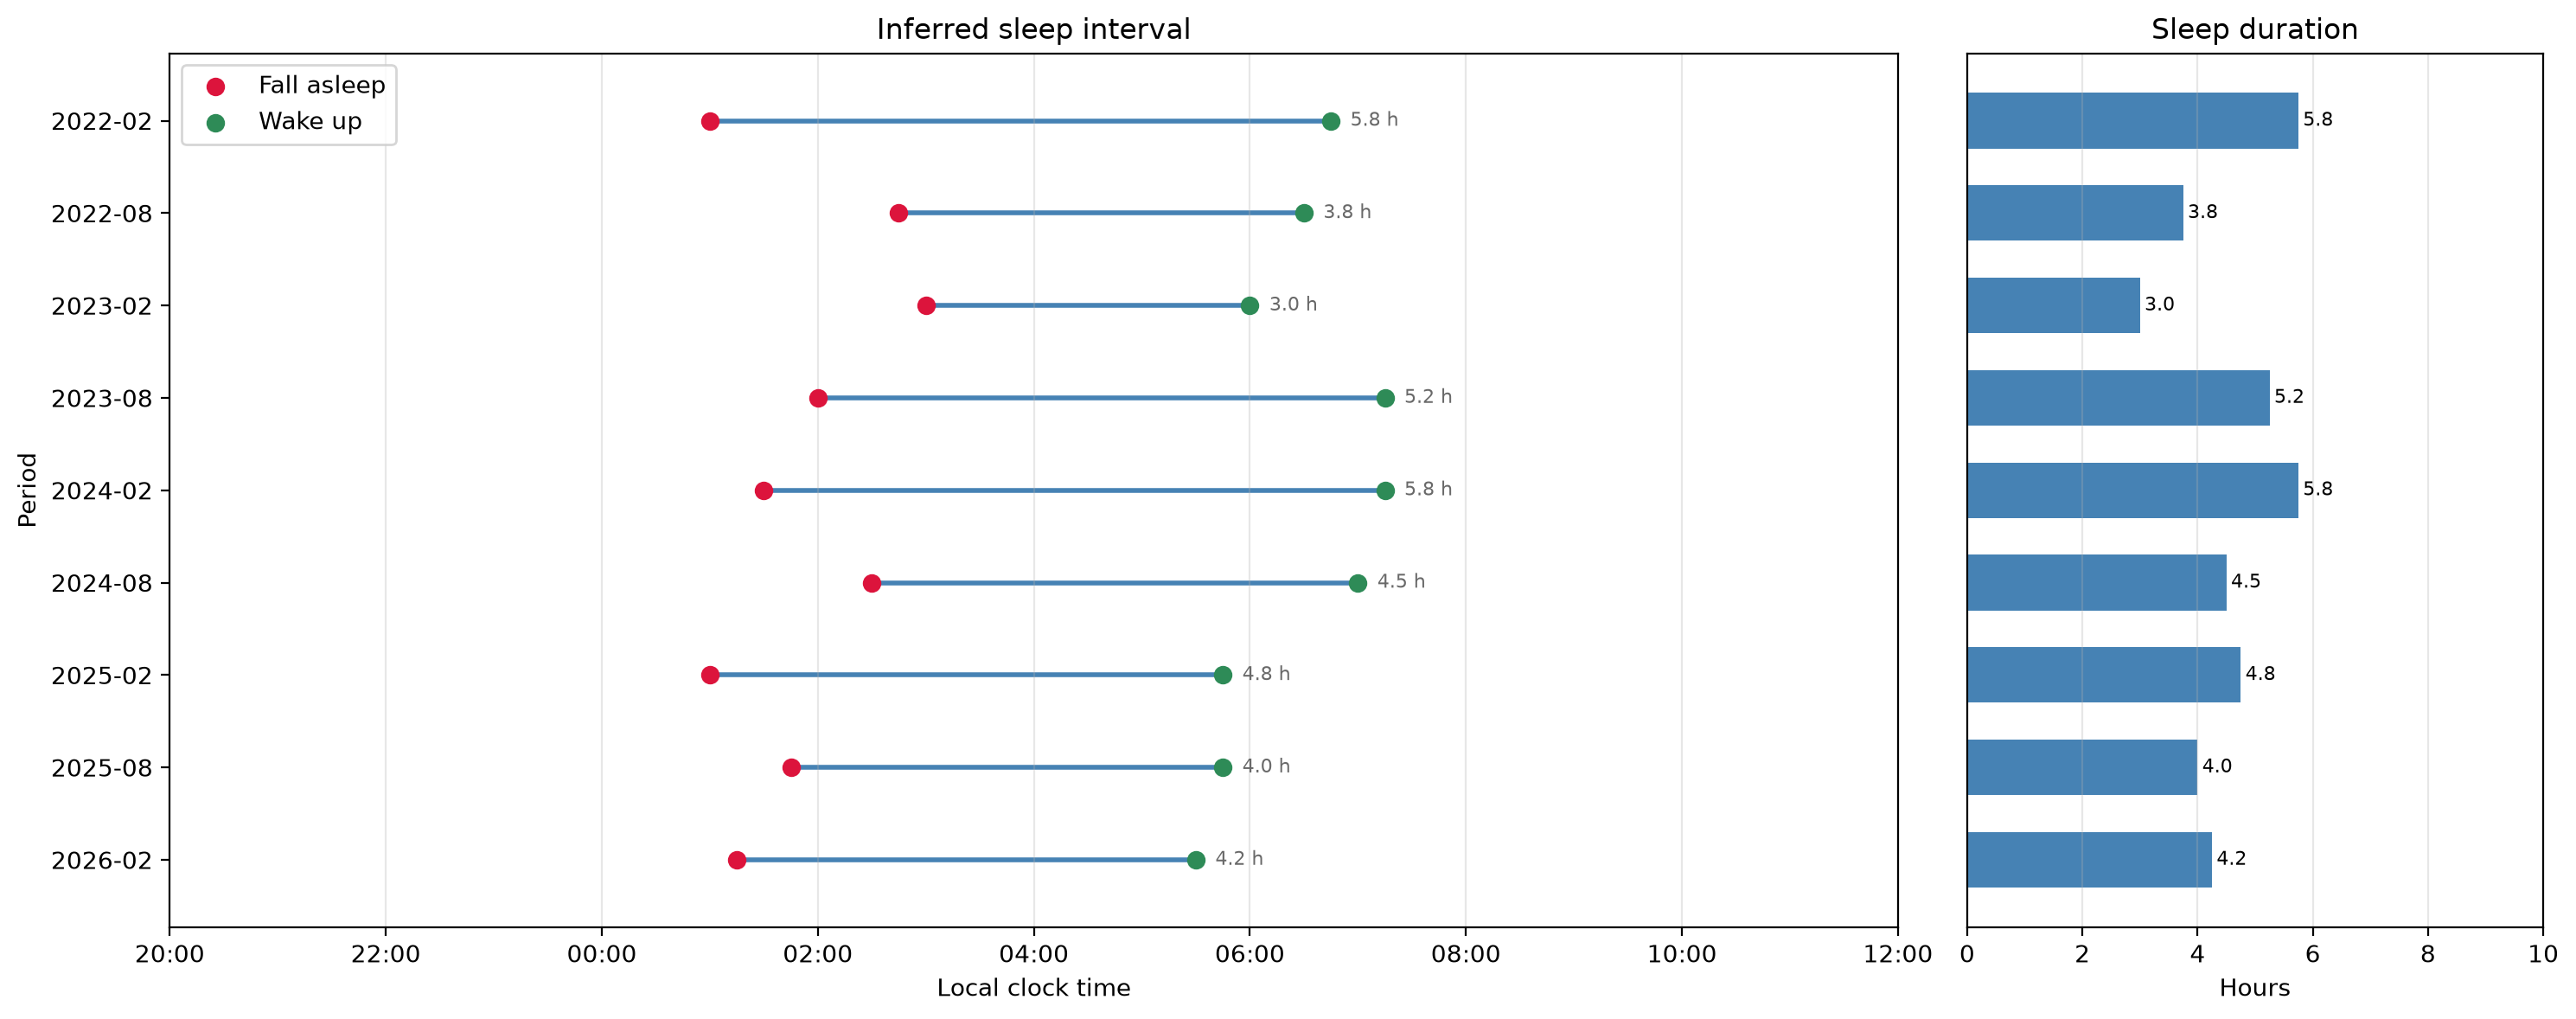

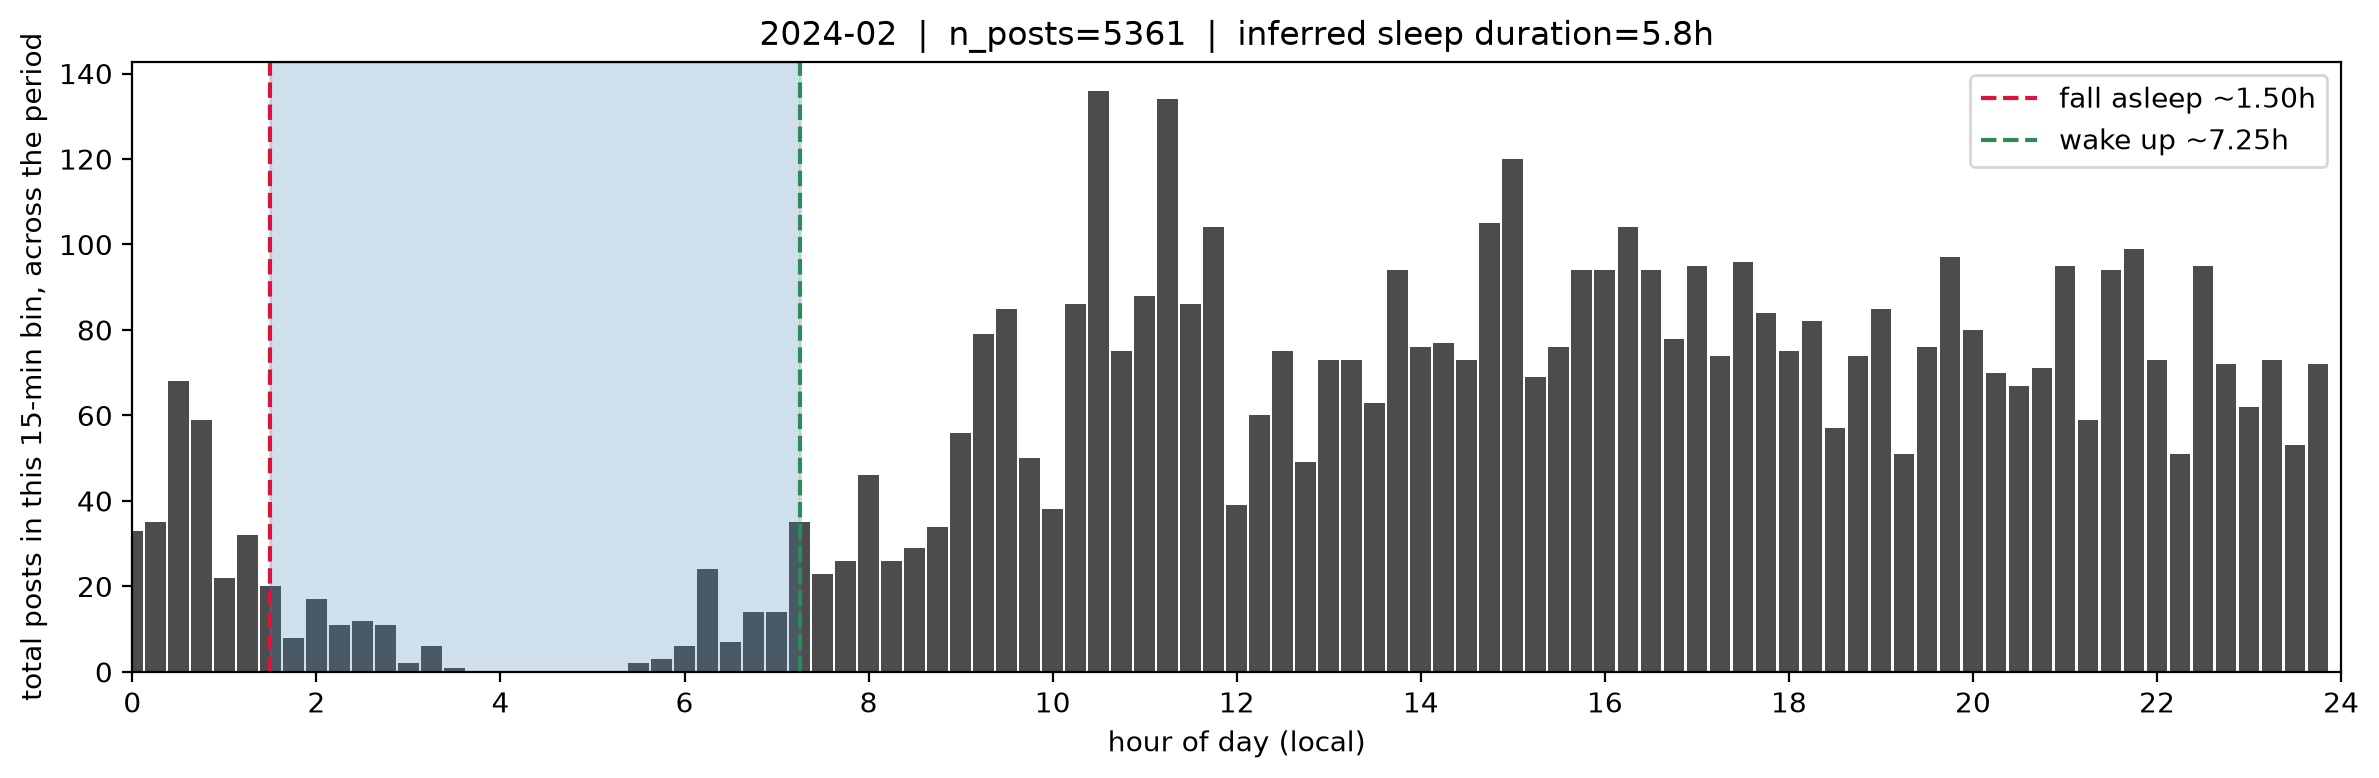

In [77]:

monthly_windows = infer_monthly_sleep_windows(hist)

plot_sleep_trend(monthly_windows)
plot_month_debug(hist, monthly_windows, "2024-02")